# Prueba de calculo de Rates

Para esta prueba voy a usar los datos que recolecté usando plot digitalizer por lo tanto pueden ser erroneos o tener leves diferencias con los reales.

Por otro lado usamos la aproximación:

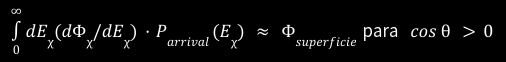

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib qt

custom_params = {
    'font.family': 'serif',
}

plt.rcParams.update(custom_params)

## Datos de flujos 

In [38]:
df_pb = pd.read_csv('Flujo_PB.csv',sep = ';')
df_md = pd.read_csv('Flujo_MD_tot.csv',sep = ';')
masa_pb = df_pb[df_pb.columns[0]]
flujo_pb = df_pb[df_pb.columns[1]]
masa_md = df_md[df_md.columns[0]]
flujo_md = df_md[df_md.columns[1]]


In [39]:
plt.plot(masa_pb, flujo_pb, '-', label='PB')
plt.plot(masa_md, flujo_md, '-', label='MD')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e1,np.max(masa_md))
plt.ylim(np.min(flujo_pb),4e-8)
plt.xlabel('Masa [MeV/c²]')
plt.ylabel('Flujo [s⁻¹ cm⁻² sr⁻¹]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.show()


Asumo que el flujo en superficie es isotrópico y por lo tanto no depende del ángulo theta para theta menor a $\pi/2$ y solo hay que multiplicar por $2\pi$ para integrar en la semiesfera que estamos considerando.

In [40]:
masa_pb = df_pb[df_pb.columns[0]]
flujo_pb =2*np.pi*df_pb[df_pb.columns[1]] 
masa_md = df_md[df_md.columns[0]]
flujo_md =2*np.pi*df_md[df_md.columns[1]]

# Datos sección eficaz

In [41]:
df_se = pd.read_csv('Seccion_eficaz_DEr_mCP.csv',sep = ';')

In [42]:
Er = df_se[df_se.columns[0]]
sigma_er = df_se[df_se.columns[1]]

In [43]:
plt.plot(Er, sigma_er, '-', label='Sección eficaz')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energía de recoil [eV]')
plt.ylabel('Sección eficaz diferencial [cm²/eV]')
plt.grid(linestyle='--', alpha=0.5)

Tengo que pasar esta sección eficaz para el caso de que tengamos $\varepsilon = 10^{-2}$

In [44]:
sigma_er = (df_se[df_se.columns[1]]/(1e-6)**2)*(1e-2)**2

In [45]:
len(masa_pb),len(masa_md)

(50, 55)

In [46]:
espectros_pb = np.zeros((len(masa_pb),len(Er)))
espectros_md = np.zeros((len(masa_md),len(Er)))
for i in range(len(masa_pb)):
    espectros_pb[i,:] = flujo_pb[i]*sigma_er

for i in range(len(masa_md)):
    espectros_md[i,:] = flujo_md[i]*sigma_er

In [47]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)
masa1 = np.logspace(1,2,5)
masa2 = np.logspace(np.log10(2e2),np.log10(8e2),15)
masa = np.concatenate((masa1,masa2))
mass_pb = []
max_pb = []
for i in range(len(masa)):
    dif  = np.abs(masa_pb-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, espectros_pb[idx,:], '-', label=f'PB, m={masa[i]:.1f} MeV/c²')
    mass_pb.append(masa_pb[idx])
    max_pb.append(np.max(espectros_pb[idx,:]))
    
mass_pb,max_pb = np.array(mass_pb),np.array(max_pb)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel('Rate [s⁻¹eV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_pb, max_pb, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [s⁻¹eV⁻¹]')

Text(0, 0.5, 'Max Rate [s⁻¹eV⁻¹]')

qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::zwp_text_input_v3_leave(wl_surface*) Got leave event for surface 0x0 with focusing surface 0x6139b9f16050


In [48]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)
masa1 = np.logspace(1,2,10)
masa2 = np.logspace(np.log10(2e2),np.log10(1e3),10)
masa = np.concatenate((masa1,masa2))
mass_md = []
max_md = []
for i in range(len(masa)):
    dif  = np.abs(masa_md-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, espectros_md[idx,:], '-', label=f'MD, m={masa[i]:.1f} MeV/c²')
    mass_md.append(masa_md[idx])
    max_md.append(np.max(espectros_md[idx,:]))
    
mass_md,max_md = np.array(mass_md),np.array(max_md)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel('Rate [s⁻¹eV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_md, max_md, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [s⁻¹eV⁻¹]')


Text(0, 0.5, 'Max Rate [s⁻¹eV⁻¹]')

qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::zwp_text_input_v3_leave(wl_surface*) Got leave event for surface 0x0 with focusing surface 0x6139ba88fb10


In [49]:
mass_md

array([ 10.18939953,  13.59468181,  15.41340017,  22.56787895,
        29.55254447,  37.1119642 ,  47.47963465,  63.04999097,
        78.08588169, 100.3748427 , 199.7571385 , 228.6029377 ,
       285.7866772 , 344.2055895 , 400.88814   , 501.0265587 ,
       541.6839655 , 739.7641476 , 846.6018881 , 973.3721963 ])

In [50]:
plt.plot(mass_pb[mass_pb>400], max_pb[mass_pb>400], '.-')
plt.plot(mass_md[mass_md>400], max_md[mass_md>400], '.-')
plt.xscale('log')
plt.xlabel('Masa [MeV/c²]')
plt.ylabel('Max Rate [s⁻¹eV⁻¹]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend(['PB','MD'])
plt.show()


Tenemos que poner el rate diferencial en unidades de DRU

$$
[DRU]= kg^{-1}day^{-1}keV^{-1}
$$

In [51]:
rho_kg = 6.02214076e23/28.0855 # [1/kg]
f_conversion = 8.64e10 # [1/(kg day keV)] ---> [1/(g s eV)]
rate_dif_pb = espectros_pb*rho_kg*(1/f_conversion)
rate_dif_md = espectros_md*rho_kg*(1/f_conversion)

In [58]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)
masa1 = np.logspace(1,2,5)
masa2 = np.logspace(np.log10(2e2),np.log10(8e2),15)
masa = np.concatenate((masa1,masa2))
mass_pb = []
max_pb = []
for i in range(len(masa)):
    dif  = np.abs(masa_pb-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, rate_dif_pb[idx,:], '-', label=f'PB, m={masa[i]:.1f} MeV/c²')
    mass_pb.append(masa_pb[idx])
    max_pb.append(np.max(rate_dif_pb[idx,:]))
    
mass_pb,max_pb = np.array(mass_pb),np.array(max_pb)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel(f'$ \\frac{{dR}}{{dt}} $[kg⁻¹day⁻¹keV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_pb, max_pb, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [kg⁻¹day⁻¹keV⁻¹]')
fig.suptitle(f'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

Text(0.5, 0.98, 'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

In [57]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)
masa1 = np.logspace(1,2,10)
masa2 = np.logspace(np.log10(2e2),np.log10(1e3),10)
masa = np.concatenate((masa1,masa2))
mass_md = []
max_md = []
for i in range(len(masa)):
    dif  = np.abs(masa_md-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, rate_dif_md[idx,:], '-', label=f'MD, m={masa[i]:.1f} MeV/c²')
    mass_md.append(masa_md[idx])
    max_md.append(np.max(rate_dif_md[idx,:]))
    
mass_md,max_md = np.array(mass_md),np.array(max_md)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel(f'$ \\frac{{dR}}{{dt}} $[kg⁻¹day⁻¹keV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_md, max_md, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [kg⁻¹day⁻¹keV⁻¹]')
fig.suptitle(f'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')


Text(0.5, 0.98, 'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

In [66]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)

masa = np.logspace(np.log10(50),np.log10(8e2),20)
mass_pb = []
max_pb = []
for i in range(len(masa)):
    dif  = np.abs(masa_pb-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, rate_dif_pb[idx,:], '-', label=f'PB, m={masa[i]:.1f} MeV/c²')
    mass_pb.append(masa_pb[idx])
    max_pb.append(np.max(rate_dif_pb[idx,:]))
    
mass_pb,max_pb = np.array(mass_pb),np.array(max_pb)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel(f'$ \\frac{{dR}}{{dt}} $[kg⁻¹day⁻¹keV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_pb, max_pb, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [kg⁻¹day⁻¹keV⁻¹]')
fig.suptitle(f'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

Text(0.5, 0.98, 'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::zwp_text_input_v3_leave(wl_surface*) Got leave event for surface 0x0 with focusing surface 0x6139baded400


In [67]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)

masa = np.logspace(np.log10(50),np.log10(8e2),20)
mass_md = []
max_md = []
for i in range(len(masa)):
    dif  = np.abs(masa_md-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, rate_dif_md[idx,:], '-', label=f'MD, m={masa[i]:.1f} MeV/c²')
    mass_md.append(masa_md[idx])
    max_md.append(np.max(rate_dif_md[idx,:]))
    
mass_md,max_md = np.array(mass_md),np.array(max_md)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel(f'$ \\frac{{dR}}{{dt}} $[kg⁻¹day⁻¹keV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_md, max_md, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [kg⁻¹day⁻¹keV⁻¹]')
fig.suptitle(f'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

Text(0.5, 0.98, 'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::zwp_text_input_v3_leave(wl_surface*) Got leave event for surface 0x0 with focusing surface 0x6139b6d9ac50


In [68]:
plt.plot(mass_pb, max_pb, '.-')
plt.plot(mass_md, max_md, '.-')
plt.xscale('log')
plt.xlabel('Masa [MeV/c²]')
plt.ylabel(f'$ \\frac{{dR}}{{dt}}$ máximo [kg⁻¹day⁻¹keV⁻¹]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend(['PB','MD'])
plt.show()


qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::zwp_text_input_v3_leave(wl_surface*) Got leave event for surface 0x0 with focusing surface 0x6139b7b49f00
